# Fitting a polymer force field with OpenFF infrastructure

This workshop is structured roughly in two parts.

**Part 1**

Part 1 is an intro to OpenFF software. Here we demonstrate how to load or build a PEG polymer,
assign parameters to it with an OpenFF force field, run a
simulation, and carry out analysis of the simulation,
all with freely available open source software.

**Part 2**

Part 2 goes deeper into what OpenFF does. Here, we show how one
could fit force field parameters for a particular chemistry.
Our first example is fitting to QM data computed at the default OpenFF
level of theory. Optionally, we show more of the knobs and levers
with two more additional fits: 
refitting to MLIP (Egret-1) data, or building a bespoke force field with PRESTO.

The tutorial makes use of the following libraries and concepts:

- [**OpenFF Toolkit**]: Core objects for representing molecules, and for constructing/parameterising force fields
- [**OpenFF Interchange**]: A parameterised system representation that exports to any supported MD engine
- [**SMIRNOFF**]: Open standard for comprehensive atomtype-free force fields using direct chemical perception via SMIRKS
- [**MDAnalysis**]: an open source library for fast, extensible analysis of MD data
- [**PyTorch**]: Python bindings to the Torch C++ machine learning library
- [**Smee**]: Differentiable computation of SMIRNOFF force field energies via PyTorch
- [**Descent**]: Fitting machinery around Smee
- [**QCArchive**]: Online archive of quantum chemical calculations and results managed by MolSSI

<div style="background:#e7f3fe; border-left:6px solid #2196F3; color:#1a1a1a; padding:12px 16px; margin:8px 0; border-radius:4px;">
<b>📘 Note:</b> for live demo purposes, this notebook has been structured to run quickly and easily on a CPU laptop. For any tasks that may be compute-heavy, require CUDA, or internet access, we have cached artifacts for downloading. However, we have also provided scripts for running this yourself, or example steps in the notebook.
</div>

[**OpenFF Toolkit**]: https://docs.openforcefield.org/projects/toolkit/en/stable/
[**OpenFF Interchange**]: https://docs.openforcefield.org/projects/interchange/en/stable/
[**MDAnalysis**]: https://www.mdanalysis.org/
[**PyTorch**]: https://pytorch.org/
[**Smee**]: https://github.com/openforcefield/smee
[**Descent**]: https://github.com/openforcefield/descent
[**QCArchive**]: https://docs.qcarchive.molssi.org/
[**SMIRNOFF**]: https://openforcefield.github.io/standards/standards/smirnoff/

## Running this notebook on Google Colab

If you're on **Google Colab**, run the next two code cells once, in order, before continuing. They:

1. **Clone the repo** (public: `lilyminium/2026-polymers`) so the workshop's `data/`, `artifacts/`, and `peg_workshop_utils.py` are on disk.
2. **Install the environment** via [`condacolab`](https://github.com/conda-incubator/condacolab), which bootstraps a full conda/mamba environment from `environment-colab.yaml` (a trimmed `environment.yaml` -- same science stack, minus local-editor tooling).

Step 2 **will restart your Colab runtime** -- that's expected, not a bug. Once it restarts, just go to `Runtime > Run all` again; both setup cells are idempotent and skip work already done, so the second pass continues straight into package installation and then the workshop itself.

If you're running locally under pixi/conda (see `README.md`), skip this section -- `IN_COLAB` evaluates to `False` and both cells no-op.

In [ ]:
import pathlib
import subprocess
import sys

IN_COLAB = "google.colab" in sys.modules
REPO_DIR = pathlib.Path("/content/2026-polymers")

if IN_COLAB:
    if not REPO_DIR.exists():
        subprocess.run(
            [
                "git", "clone", "--depth", "1",
                "https://github.com/lilyminium/2026-polymers.git", str(REPO_DIR),
            ],
            check=True,
        )
    import os

    os.chdir(REPO_DIR)
    if str(REPO_DIR) not in sys.path:
        sys.path.insert(0, str(REPO_DIR))
    print(f"cwd: {pathlib.Path.cwd()}")

In [ ]:
if IN_COLAB:
    try:
        import condacolab

        condacolab.check()
    except (ImportError, AssertionError):
        %pip install -q "https://github.com/conda-incubator/condacolab/archive/main.zip"
        import condacolab

        condacolab.install()  # restarts the runtime -- then Runtime > Run all again

In [ ]:
if IN_COLAB:
    import condacolab

    condacolab.check()
    !mamba env update -n base -f environment-colab.yaml -q

## 0. Setup

Below we set up some niceties: basic imports, suppressing some warnings that are not useful, and setting up paths to directories.

We also set up the colour palette for the various force fields we plan to work with for consistent plotting.

In [1]:
import pathlib
import sys
import warnings

# make rdkit pretty
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem import Draw

IPythonConsole.ipython_useSVG = True
IPythonConsole.molSize = (400, 400)

# an unimportant deprecation warning from MDAnalysis
warnings.filterwarnings("ignore", message=".*DCDReader currently makes.*")
# unimportant warning about missing dependency
warnings.filterwarnings("ignore", message=".*OpenEye is not installed.*")

# Workshop paths
DATA = pathlib.Path("data")
ART = pathlib.Path("artifacts")

# Reference MD data (vendored under data/; see data/wasp_reference/README.md).
# re-residued into OCC monomers + caps (data/wasp_reference/build_peg_solv_36mer.py)
WASP_PDB = DATA / "wasp_reference" / "peg_solv_36mer.pdb"  

# colour palettes and legends
FF_COLORS = {
    "baseline": "#888888",
    "dft": "#e07a3c",
    "egret": "#1976d2",
    "presto": "#2e7d32"
}
TEST_COLORS = {
    "DFT test (B3LYP)": FF_COLORS["dft"],
    "Egret-1 test (MLIP)": FF_COLORS["egret"]
}

# Part 1: Intro to OpenFF -- from SMILES and PDB to simulation

Here we introduce the OpenFF software stack with some common tasks: parsing a molecule from SMILES, working with a molecule from another package, or loading a molecule from PDB. We then assign parameters to it with an OpenFF force field, run a simulation, and measure a physical property.

## 1.1 OpenFF: from SMILES to Interchange

Going from a SMILES string to a parameterised, simulatable system takes only a few lines.

First, [creating an OpenFF Molecule can be done a number of ways,](https://docs.openforcefield.org/projects/toolkit/en/stable/users/molecule_cookbook.html) but the easiest way is probably from SMILES. 

Before diving in, a quick map of the core OpenFF objects you'll see throughout this notebook:

- **`Molecule`** -- a chemical graph (atoms, bonds, formal charges) plus optional 3D conformers. No force field involved yet.
- **`Topology`** -- one or more `Molecule`s arranged into a system (e.g. a polymer plus water).
- **`ForceField`** -- a SMIRNOFF parameter set (e.g. Sage) that hasn't been applied to anything yet.
- **`Interchange`** -- the result of applying a `ForceField` to a `Topology`: a fully parameterized, engine-independent system ready to simulate or export.

Roughly: `Molecule`/`Topology` describe *what's there*, `ForceField` describes *how to parameterize it*, and `Interchange` is *the parameterized result*.

[H][C]([H])([H])[C]([H])([H])[O][C]([H])([H])[C]([H])([H])[O][C]([H])([H])[C]([H])([H])[H]  (22 atoms, 21 bonds)


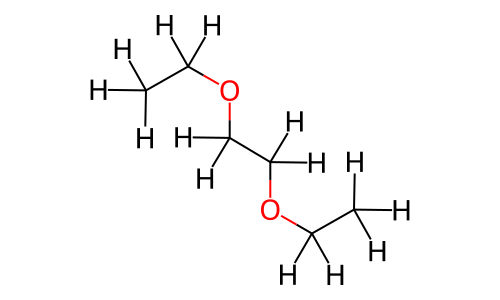

In [2]:
from openff.toolkit import Molecule

small_mol = Molecule.from_smiles("CCOCCOCC")

print(f"{small_mol.to_smiles()}  ({small_mol.n_atoms} atoms, {small_mol.n_bonds} bonds)")
# No coordinates yet -- visualize() draws the 2D graph with RDKit.
small_mol.visualize()

You can generate conformers from within the OpenFF toolkit (which typically calls another cheminformatics backend, either OpenEye if you have a license or RDKit if not, to do the heavy lifting).

In [3]:
small_mol.generate_conformers(n_conformers=1)

# now that there's a conformer, we can view 3D coordinates
small_mol.visualize(backend="nglview")

NGLWidget()

Below we can load a pre-installed ForceField. (You can also pass a path to a local file too; note it has to be an `.offxml` format force field). We load Sage 2.3.0 here, the latest OpenFF release.

We can use a ForceField to assign parameters and create a parameterized system known as an Interchange.

A `ForceField` like Sage is organized into **parameter handlers** -- one per
interaction type (`Bonds`, `Angles`, `ProperTorsions`, `vdW`, `Electrostatics`, ...).
Each handler holds a list of parameters, each tagged with a **SMIRKS** pattern (a
SMARTS-like substructure query). When you call `create_interchange`, OpenFF walks
the molecule, finds the most specific SMIRKS match for every bond/angle/torsion/atom,
and assigns that parameter. You can see the handlers Sage defines with
`init_ff.registered_parameter_handlers`.

In [4]:
from openff.toolkit import ForceField

# openff-2.3.0.offxml is installed in the environment;
# you can also run ForceField("path/to/your.offxml") to load a custom FF file.
init_ff = ForceField("openff-2.3.0.offxml")

small_interchange = init_ff.create_interchange(small_mol.to_topology())
small_interchange

Interchange with 7 collections, non-periodic topology with 22 atoms.

An Interchange contains the parameters assigned to the molecule, positions, box vectors if there are any -- basically everything necessary to output from there to a simulation.

Why not go straight from `ForceField` + `Topology` to a simulation engine? `Interchange`
is OpenFF's own engine-independent representation -- it keeps track of parameter
provenance and lets you export the *same* parameterized system to OpenMM, GROMACS,
LAMMPS, or Amber (see below) without re-parameterizing separately for each one.

In [5]:
small_interchange.positions

Magnitude,[[-0.29405351924285306 0.006912365129772161 0.08693695818702567] [-0.2627165294043212 0.0031966653866585207 -0.06277854555195851] [-0.1697718066935767 -0.09503031028991463 -0.08818770491138282] [-0.04874409440123172 -0.07421476533062514 -0.018644083526406067] [0.017513181376482702 0.055093956352649784 -0.05416970840171523] [0.13525647581518177 0.07439308734193634 0.01437027118067467] [0.23228173522853188 -0.019219280453199185 -0.007219945915438354] [0.35490889122818103 0.020899349409057653 0.07530595868075968] [-0.27906488364451754 -0.0903241609746703 0.13516679305969137] [-0.2244397222218818 0.07861982349131692 0.1350599854738202] [-0.39839451701926387 0.0429250389735255 0.09667816336769963] [-0.23997107183855387 0.1027934229777243 -0.10019642654915337] [-0.358804761581484 -0.026546299045831327 -0.11407582271504] [-0.08281492235971487 -0.06049866825568641 0.08824310454070677] [0.013818086694783184 -0.16284813324310032 -0.019440793703671] [-0.05430929502047071 0.13783494160287044 -0.02723606122615536] [0.03827972583830222 0.06557441168977338 -0.16252540878680583] [0.267195663858517 -0.029236380082813547 -0.1114515639333389] [0.20142914446237803 -0.1189364728763937 0.026817791714726612] [0.31927507981819814 0.07618444968677884 0.1628924829905386] [0.4131343518477402 -0.07070318364389573 0.1027488012010045] [0.419992787259581 0.08313014215406347 0.011695949199101835]]
Units,nanometer


In [6]:
small_interchange.box # returns None -- there was no box created!

From here, you can easily calculate the energies associated with a system using OpenMM.

In [7]:
from openff.interchange.drivers import get_openmm_energies

energy_before = get_openmm_energies(small_interchange)
print(energy_before)

Energies:

Bond:          		12.240348199986116 kilojoule / mole
Angle:         		23.637966317326683 kilojoule / mole
Torsion:       		35.11812732034849 kilojoule / mole
RBTorsion:     		None
Nonbonded:     		75.54807217764227 kilojoule / mole
vdW:           		None
Electrostatics:		None



Note above, the vdW and electrostatics energies are bundled together into Nonbonded. You can separate them as below:

In [8]:
energy_before = get_openmm_energies(small_interchange, combine_nonbonded_forces=False)
print(energy_before)

Energies:

Bond:          		12.240348199986116 kilojoule / mole
Angle:         		23.637966317326683 kilojoule / mole
Torsion:       		35.11812732034849 kilojoule / mole
RBTorsion:     		None
Nonbonded:     		None
vdW:           		72.09872731243004 kilojoule / mole
Electrostatics:		3.4493447839199387 kilojoule / mole



You can also minimize with OpenMM using a single line.

In [9]:
# minimize with OpenMM
small_interchange.minimize()
energy_after = get_openmm_energies(small_interchange)
print(energy_after)

e0 = energy_before.total_energy.m_as("kilocalorie/mole")
e1 = energy_after.total_energy.m_as("kilocalorie/mole")
print(f"\nTotal energy: {e0:.1f} -> {e1:.1f} kcal/mol  (relaxed by {e0 - e1:.1f})")

Energies:

Bond:          		0.9549094502731932 kilojoule / mole
Angle:         		3.8422723892150397 kilojoule / mole
Torsion:       		25.16850851094019 kilojoule / mole
RBTorsion:     		None
Nonbonded:     		5.192828311650396 kilojoule / mole
vdW:           		None
Electrostatics:		None


Total energy: 35.0 -> 8.4 kcal/mol  (relaxed by 26.6)


## 1.2 From Interchange to simulation

An `Interchange` can be exported to a number of [common simulation engine formats](https://docs.openforcefield.org/projects/interchange/en/stable/using/output.html). Below, we demonstrate using OpenMM to simulate.

In [10]:
import tqdm
import openmm
from openmm import app, unit as ommunit

small_sim = small_interchange.to_openmm_simulation(
    integrator=openmm.LangevinIntegrator(
        300.0 * ommunit.kelvin,
        1.0 / ommunit.picosecond,
        2.0 * ommunit.femtosecond,
    ),
)

# first write interchange to PDB so MDAnalysis/NGLView can load it
small_top = ART / "small_md_top.pdb"
small_interchange.to_pdb(small_top)

# write simulation to DCD so we can visualize too
small_traj = ART / "small_md_traj.dcd"
small_sim.reporters.append(app.DCDReporter(str(small_traj), 100))
small_sim.context.setVelocitiesToTemperature(300.0 * ommunit.kelvin)

print("Running 2 ps of vacuum MD on CCOCCOCC...")

# tqdm gives us progress bars
for _ in tqdm.tqdm(range(1_000), desc="vacuum MD"):  # 1 000 * 2 fs = 2 ps
    small_sim.step(10)

energy = small_sim.context.getState(getEnergy=True).getPotentialEnergy()
print(f"  final potential energy : {energy.value_in_unit(ommunit.kilocalorie_per_mole):.2f} kcal/mol")

Running 2 ps of vacuum MD on CCOCCOCC...


vacuum MD: 100%|██████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 1051.47it/s]

  final potential energy : 17.15 kcal/mol


We can use NGLView to watch the trajectory in the notebook.

In [11]:
import nglview
import MDAnalysis as mda

small_u = mda.Universe(small_top, small_traj)
print(f"{len(small_u.trajectory)} frames, {small_u.atoms.n_atoms} atoms")
nglview.show_mdanalysis(small_u)

100 frames, 22 atoms


/Users/lily/pydev/workshops/2026-polymers/.pixi/envs/default/lib/python3.12/site-packages/MDAnalysis/coordinates/DCD.py:171: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


NGLWidget(max_frame=99)

Interchange can also export to to GROMACS, LAMMPS, Amber, and other engines
without re-parameterising, e.g. below we write GROMACS input — a `.top` topology and a
`.gro` coordinate file. (GROMACS 2020+ requires a periodic box, so we give the
vacuum system a generous cubic box first.)

See the [Interchange "Exporting" docs](https://docs.openforcefield.org/projects/interchange/en/stable/using/output.html)
for the full list of supported engines and exporters (`to_gromacs`, `to_lammps`,
`to_amber`, ...)

In [12]:
from openff.units import unit

# GROMACS (2020+) needs a periodic box; give the vacuum system a generous cubic
# box (irrelevant to the gas-phase energy, just required by the exporter).
small_interchange.box = unit.Quantity([3.0, 3.0, 3.0], unit.nanometer)

# this writes both small_gmx.top and small_gmx.gro
small_interchange.to_gromacs("small_gmx")

In [13]:
%%bash

# show the top 30 lines of small_gmx.top and small_gmx.gro
echo "===== small_gmx.top ====="
head -n 30 small_gmx.top 

echo
echo "===== small_gmx.gro ====="
head -n 30 small_gmx.gro

===== small_gmx.top =====
[ defaults ]
; nbfunc	comb-rule	gen-pairs	fudgeLJ	fudgeQQ
     1	     2	yes   	0.500000	0.833333

[ atomtypes ]
;type, bondingtype, atomic_number, mass, charge, ptype, sigma, epsilon
MOL0_0     	     6	12.01078	0.0000000000000000	A    	0.3387971073428981	0.5044644278506009
MOL0_1     	     6	12.01078	0.0000000000000000	A    	0.3387971073428981	0.5044644278506009
MOL0_2     	     8	15.99943	0.0000000000000000	A    	0.3033376560335655	0.3570019770949033
MOL0_3     	     6	12.01078	0.0000000000000000	A    	0.3387971073428981	0.5044644278506009
MOL0_4     	     6	12.01078	0.0000000000000000	A    	0.3387971073428981	0.5044644278506009
MOL0_5     	     8	15.99943	0.0000000000000000	A    	0.3033376560335655	0.3570019770949033
MOL0_6     	     6	12.01078	0.0000000000000000	A    	0.3387971073428981	0.5044644278506009
MOL0_7     	     6	12.01078	0.0000000000000000	A    	0.3387971073428981	0.5044644278506009
MOL0_8     	     1	1.007947	0.0000000000000000	A    	0.26639341

## 1.3 Build a polymer from SMILES and convert to Interchange

Let's move onto polymers. OpenFF does not have many tools to deal with polymers
ourselves, but our interoperability with RDKit means we can turn to other excellent
community tools instead with minimal overhead.

Today we use [**SwiftPol**](https://github.com/matta-research-group/SwiftPol),
which can build a polymer from a monomer SMILES plus a reaction SMARTS. We mark the
reaction sites with iodine handles: the monomer `IOCCI` (one ethylene-oxide
unit, `I–O–CH₂–CH₂–I`) has a `C–O–I` end and a `C–I` end, and the reaction
condenses a `C–I` + a `C–O–I` into a `C–O–C` ether (releasing I–I).

None of this SwiftPol/RDKit machinery is OpenFF-specific. All OpenFF actually needs,
from any molecule-building route, is a valid molecular graph -- bonds, formal charges,
explicit hydrogens -- that it can load via `Molecule.from_rdkit` (or `from_smiles`,
`from_pdb`, ...). SwiftPol and RDKit below are just one convenient way to build that
graph for a polymer; OpenFF takes back over once we have `peg` as a `Molecule`.


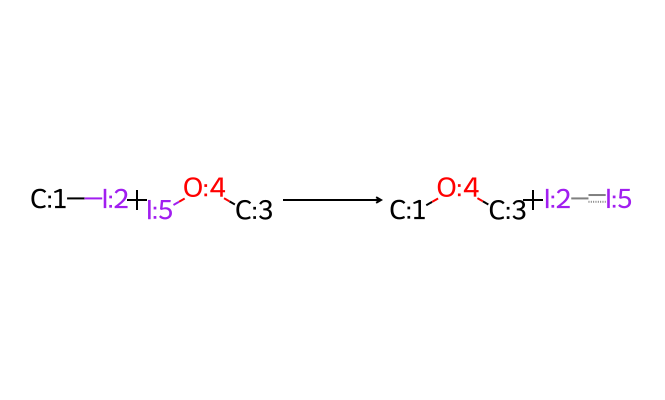

In [14]:
from rdkit import Chem
from rdkit.Chem import AllChem

MONOMER = "IOCCI"

REACTION_SMARTS = (
    "[C:1]-[I:2].[C:3]-[O:4]-[I:5]"
    ">>[C:1]-[O:4]-[C:3].[I:2][I:5]"
)

# A C-I end and a C-O-I end condense into a C-O-C ether bond, releasing I-I.
rxn = AllChem.ReactionFromSmarts(REACTION_SMARTS)
rxn

We also cap both ends with methyls to fit the pattern $C-(OCC)_{36}-OC$.
`build_polymer` inserts the start cap from its `terminal=` group and we append a
reactive methoxy cap (`IOC`) as the final monomer.

In [15]:
from swiftpol import build

N_MONOMERS = 36
CAP_R = "IOC"
CAP_L = "C"

rdmol = build.build_polymer(
    "A" * N_MONOMERS + "B",
    monomer_list=[MONOMER, CAP_R],
    reaction=rxn,
    terminal=CAP_L,
)

# SwiftPol can leave radical electrons at the joins, which OpenFF rejects;
# zero them and re-sanitise.
for atom in rdmol.GetAtoms():
    atom.SetNumRadicalElectrons(0)
Chem.SanitizeMol(rdmol)
# OpenFF also generally requires all Hs to be specified
rdmol = Chem.AddHs(rdmol)
Chem.SanitizeMol(rdmol)

peg = Molecule.from_rdkit(rdmol, allow_undefined_stereo=True)
print(f"PEG-{N_MONOMERS}: {peg.n_atoms} atoms")

PEG-36: 261 atoms


You can view the chain with RDKit:

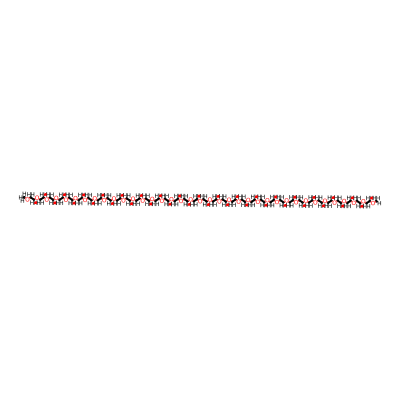

In [16]:
rdmol

The RDKit molecule has some added atom metadata that is unnecessary and will be a bit confusing so we clear it in OpenFF.

In [17]:
for atom in peg.atoms:
    atom.metadata.clear()

And we can convert to an Interchange as above.

In [18]:
peg.generate_conformers(n_conformers=1)
peg_interchange = init_ff.create_interchange(peg.to_topology())
print("PEG-36 single-point energy (Sage 2.3.0):")
print(get_openmm_energies(peg_interchange))

PEG-36 single-point energy (Sage 2.3.0):
Energies:

Bond:          		488.9200227966995 kilojoule / mole
Angle:         		1330.8497066253851 kilojoule / mole
Torsion:       		358.54103184097914 kilojoule / mole
RBTorsion:     		None
Nonbonded:     		1586.2448931607883 kilojoule / mole
vdW:           		None
Electrostatics:		None



## 1.3 Simulating a polymer in explicit water from PDB.

The properties we ultimately care about are typically condensed-phase.
In this section we demonstrate how to get and work with a molecule in water.


### Packing with Packmol
Firstly, if starting from zero, we can pack a box with water using
[OpenFF Packmol](https://github.com/openforcefield/openff-packmol).

<div style="background:#fff8e1; border-left:6px solid #ffc107; color:#1a1a1a; padding:12px 16px; margin:8px 0; border-radius:4px;">
<b>⚠️ Warning:</b> This can take up to a minute to run.
</div>

In [19]:
from openff.packmol import RHOMBIC_DODECAHEDRON, pack_box

# we need to pass water as well!
water = Molecule.from_smiles("O")
water.generate_conformers(n_conformers=1)

packmol_top = pack_box(
    molecules=[peg, water],
    number_of_copies=[1, 1000],
    target_density=1 * unit.grams / unit.mL,
)
packmol_interchange = init_ff.create_interchange(packmol_top)

# view the packed box
packmol_pdb = "artifacts/packmol_interchange.pdb"
packmol_interchange.to_pdb(packmol_pdb)
nglview.show_mdanalysis(
    mda.Universe(packmol_pdb)
)

NGLWidget()

From an Interchange, we can convert to a simulation engine as above.

**Why is loading from PDB harder than from SMILES?** A PDB file records atomic
positions (and sometimes bonds, via `CONECT` records), but usually *not* enough
chemistry for OpenFF to parameterize it directly -- formal charges, bond orders, and
which residue each atom belongs to. OpenFF needs to recover that information before
it can assign parameters. Which method you use below depends on what your PDB gives you:

| Your PDB has... | Use |
|---|---|
| `CONECT` records (bonds) | substructure/SMILES matching (below) |
| No `CONECT`, but consistent residue/atom names | atom-name matching against a residue library (below) |
| Standard residues (water, ions, amino acids) | looked up automatically from the PDB Chemical Component Dictionary (CCD) |

### Reading an existing structure from PDB.

New updates to OpenFF infrastructure have enabled us to easily
start from a pre-equilibrated structure. This is especially handy
for polymers and other large molecules that can have long
equilibration times. We borrow a PDB from 
[Davel et al.](https://pubs.acs.org/doi/10.1021/acs.jcim.3c01691)
([GitHub](https://github.com/shirtsgroup/WaSP_simulations/tree/main/wasp_sims/peg_modified/Espaloma-AM1-BCC/conf1)) and show two ways of loading it into a structure OpenFF can work with.

<div style="background:#fff8e1; border-left:6px solid #ffc107; color:#1a1a1a; padding:12px 16px; margin:8px 0; border-radius:4px;">
<b>⚠️ Note:</b> Even with recent updates to OpenFF, a PDB needs certain information for us to parse it easily;
either CONECT records denoting bonds for the method below, or consistent atom names in the PDB file for parsing with OpenFF Pablo.
To that end we had to reformat Davel's PDB file and add information, see the README.md in data/ for more.
</div>

#### Loading with Pablo


[`openff-pablo`](https://github.com/openforcefield/openff-pablo) was developed
to read PDBs by either matching residue and atom names against a residue library
(required if there are no CONECT records)
or matching monomer substructures against the PDB (requires CONECT records).
Standard residues such as water, ions, amino acids, etc are looked up in the
PDB Chemical Component Dictionary (CCD) automatically;
for a *non-standard* residue, you can supply a `ResidueDefinition` with connection
points, and optionally atom names if necessary. Below we show both ways.

Similar to SwiftPol above we will map the polymer by defining the repeating monomer unit,
start cap, and end cap below; water comes from the CCD for free.

In [21]:
from openff.pablo import ResidueDefinition, topology_from_pdb
from openff.pablo.residue import BondDefinition
# pull in STD_CCD_CACHE for water
from openff.pablo import STD_CCD_CACHE

**Matching with atom names**

Many PDB files do not have CONECT records, but do have consistent residue and atom names. If your PDB file is like this, you can read it in by telling Pablo what residues and atoms correspond with what SMILES molecule.

In [22]:
# Inter-residue bond: a residue's C2 bonds the NEXT residue's O1 (the PEG ether).
ETHER = BondDefinition.with_defaults("C2", "O1", order=1)

CAP_L = ResidueDefinition.from_smiles(
    mapped_smiles="[C:1]([H:2])([H:3])([H:4])[H:5]",
    atom_names={1: "C2", 2: "H21", 3: "H22", 4: "H23", 5: "H24"},
    residue_name="CPL", leaving_atoms=(5,), linking_bond=ETHER,
)
OCC = ResidueDefinition.from_smiles(
    mapped_smiles="[O:1]([C:2]([H:4])([H:5])[C:3]([H:6])([H:7])[H:9])[H:8]",
    atom_names={1: "O1", 2: "C1", 3: "C2", 4: "H11", 5: "H12",
                6: "H21", 7: "H22", 8: "HO1", 9: "H23"},
    residue_name="OCC", leaving_atoms=(8, 9), linking_bond=ETHER,
)
CAP_R = ResidueDefinition.from_smiles(
    mapped_smiles="[O:1]([C:2]([H:3])([H:4])[H:5])[H:6]",
    atom_names={1: "O1", 2: "C2", 3: "H21", 4: "H22", 5: "H23", 6: "HO1"},
    residue_name="CPR", leaving_atoms=(6,), linking_bond=ETHER,
)

# Water resolves from the CCD; we pass only the three custom PEG residues.
pablo_top = topology_from_pdb(
    WASP_PDB, residue_library=STD_CCD_CACHE.with_([CAP_L, OCC, CAP_R])
)
print(f"Pablo read {pablo_top.n_atoms} atoms in {pablo_top.n_molecules} molecules.")

Pablo read 42444 atoms in 14062 molecules.


**Loading with substructures**

What is usually easier, if your PDB file has CONECT records, is simply using SMILES to map the polymer directly. Note this is a bit slower than the method above, but only minorly -- for me, the cell below takes 20 seconds, whereas the cell above uses 15 seconds.

In [23]:
CAP_L = ResidueDefinition.anon_from_smiles_marked_leaving("C[H:1]")
OCC = ResidueDefinition.anon_from_smiles_marked_leaving("O(CC[H:9])[H:8]")
CAP_R = ResidueDefinition.anon_from_smiles_marked_leaving("O(C)[H:6]")

pablo_top_simple = topology_from_pdb(
    WASP_PDB,
    additional_definitions=[CAP_L, OCC, CAP_R],
)

### Simulating from a pre-equilibrated structure

Now that we have created an OpenFF Topology, we can convert to an Interchange and simulate! If you inspect the Interchange, you'll see that the coordinates themselves come from the PDB, so we can start from a box that's already roughly pre-equilibrated.

In [24]:
interchange = init_ff.create_interchange(pablo_top)
interchange.positions[:100]

<Quantity([[4.0436 4.1207 4.263 ]
 [3.9769 4.055  4.2064]
 [4.028  4.102  4.3697]
 [4.0164 4.2244 4.2416]
 [4.1798 4.0956 4.2262]
 [4.272  4.1831 4.2939]
 [4.2819 4.1537 4.3988]
 [4.2363 4.2865 4.2922]
 [4.4088 4.1777 4.2267]
 [4.445  4.0745 4.2268]
 [4.4797 4.2374 4.2848]
 [4.3999 4.23   4.0929]
 [4.5197 4.2114 4.0158]
 [4.5481 4.1058 4.0136]
 [4.6027 4.2678 4.0595]
 [4.4949 4.2592 3.8729]
 [4.4724 4.3663 3.8742]
 [4.5856 4.2449 3.8136]
 [4.3848 4.1848 3.8175]
 [4.367  4.1984 3.6751]
 [4.4632 4.1902 3.6237]
 [4.3041 4.1165 3.6389]
 [4.3017 4.3315 3.6367]
 [4.2979 4.339  3.5277]
 [4.3623 4.4151 3.6729]
 [4.1696 4.3393 3.693 ]
 [4.0885 4.4453 3.6381]
 [4.0191 4.4827 3.714 ]
 [4.1511 4.5301 3.6088]
 [4.0097 4.3978 3.5157]
 [3.9721 4.485  3.4615]
 [4.0765 4.3432 3.4485]
 [3.8984 4.316  3.5562]
 [3.8188 4.2653 3.4473]
 [3.8037 4.3442 3.3731]
 [3.7199 4.2372 3.4846]
 [3.882  4.143  3.3781]
 [3.9856 4.1644 3.3502]
 [3.8273 4.1255 3.2849]
 [3.8743 4.0225 3.4576]
 [3.9663 4.0194 3.5687]
 [4.0649 4.0525 3.535 ]
 [3.9354 4.0875 3.6486]
 [3.9781 3.877  3.6247]
 [4.0765 3.8678 3.6717]
 [3.9755 3.8049 3.5425]
 [3.8768 3.8471 3.7235]
 [3.7448 3.8293 3.6689]
 [3.7098 3.9236 3.6259]
 [3.7465 3.7547 3.589 ]
 [3.6446 3.7863 3.7759]
 [3.6501 3.8555 3.8605]
 [3.5441 3.7944 3.7336]
 [3.6695 3.651  3.82  ]
 [3.5519 3.5808 3.8665]
 [3.5827 3.4808 3.8985]
 [3.4802 3.5673 3.785 ]
 [3.4829 3.6512 3.9849]
 [3.4422 3.5752 4.0522]
 [3.5567 3.7093 4.041 ]
 [3.3739 3.732  3.937 ]
 [3.3538 3.8535 4.0111]
 [3.4258 3.9297 3.9799]
 [3.37   3.8351 4.1177]
 [3.2117 3.9061 3.9911]
 [3.1931 3.981  4.0687]
 [3.1402 3.8248 4.0071]
 [3.1906 3.968  3.8626]
 [3.1891 3.8778 3.7504]
 [3.2907 3.867  3.7114]
 [3.1556 3.7779 3.7799]
 [3.0987 3.9329 3.6397]
 [3.1356 4.0317 3.6104]
 [3.1074 3.8684 3.5518]
 [2.9606 3.9428 3.6811]
 [2.8895 3.8175 3.6834]
 [2.9411 3.7442 3.7461]
 [2.8839 3.7755 3.5825]
 [2.7477 3.8385 3.7364]
 [2.701  3.9203 3.6807]
 [2.6893 3.7484 3.7157]
 [2.7475 3.8685 3.8781]
 [2.7362 3.7511 3.9613]
 [2.8217 3.6851 3.9439]
 [2.646  3.6952 3.9351]
 [2.7299 3.786  4.1104]
 [2.821  3.8402 4.1375]
 [2.7292 3.693  4.1679]
 [2.6104 3.8612 4.1413]
 [2.6394 3.9938 4.1888]
 [2.7054 4.0443 4.1177]
 [2.6917 3.9886 4.2848]
 [2.512  4.0763 4.2048]
 [2.5398 4.1804 4.2235]
 [2.457  4.0748 4.1102]
 [2.4318 4.0275 4.3143]
 [2.3001 4.0862 4.3199]
 [2.305  4.1934 4.299 ]
 [2.26   4.0763 4.4212]
 [2.2023 4.0212 4.2211]], 'nanometer')>

Now let's simulate.

In [25]:
import openmm
from openmm import app
from openmm import unit as ommunit

N_STEPS = 2_500        # notebook demo: 5 ps
# N_STEPS = 250_000    # GPU setting: 0.5 ns

# create openmm objects
TEMPERATURE = 300.0 * ommunit.kelvin
barostat = openmm.MonteCarloBarostat(1.0 * ommunit.bar, TEMPERATURE, 25)
sim = interchange.to_openmm_simulation(
    integrator=openmm.LangevinMiddleIntegrator(
        TEMPERATURE,
        1.0 / ommunit.picosecond,          # friction
        2.0 * ommunit.femtosecond          # timestep
    ),
    additional_forces=[barostat],          # MonteCarloBarostat for NPT
)

# minimize
sim.minimizeEnergy()
sim.context.setVelocitiesToTemperature(TEMPERATURE)

# set up reporters to write output to file
csvfile = str(ART / "explicit_demo_state.csv")
sim.reporters.append(
    app.StateDataReporter(
        csvfile, 100,
        step=True, time=True, temperature=True, density=True
    )
)
dcdfile = str(ART / "explicit_demo_traj.dcd")
sim.reporters.append(
    app.DCDReporter(dcdfile, 100)
)

# simulate. tqdm shows a progress bar but don't typically recommend running the simulation 1 step at a time
# as that is much less efficient than calling sim.step(n_steps)
for _ in tqdm.tqdm(range(N_STEPS), desc="simulating"):
    sim.step(1)

simulating: 100%|██████████████████████████████████████████████████████████████████████████████| 2500/2500 [00:07<00:00, 338.84it/s]


Let's have a look at the state file.

In [26]:
import pandas as pd

df = pd.read_csv(csvfile)
df.head()

,"#""Step""",Time (ps),Temperature (K),Density (g/mL)
0,100,0.2,166.978232,1.009665
1,200,0.4,191.358254,1.009665
2,300,0.6,209.077461,1.009665
3,400,0.8,224.412841,1.007162
4,500,1.0,236.003861,1.001694


Below we can plot the density. It hasn't stabilised yet, which is a warning sign that the system is likely not equilibrated and this data should not be used for analysis!

<Axes: xlabel='Time (ps)'>

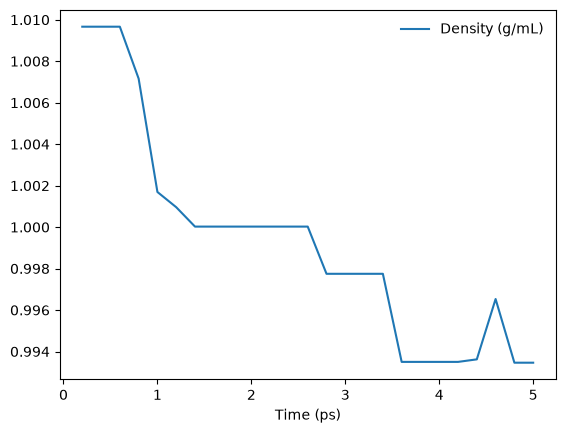

In [27]:
df.plot("Time (ps)", "Density (g/mL)")

Instead, we have included a pre-computed trajectory (with water stripped out for size) that was equilibrated and then further simulated for 10 ns. We use MDAnalysis to compute the radius of gyration from this trajectory, and compare it to an experimental relationship from [Devanand and Selser 1995](https://pubs.acs.org/doi/10.1021/ma00022a008) below (Eq 2 in the paper):

$$
R_g = 0.215 M_{w}^{0.583 ± 0.031} Å
$$

/Users/lily/pydev/workshops/2026-polymers/.pixi/envs/default/lib/python3.12/site-packages/MDAnalysis/coordinates/DCD.py:171: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


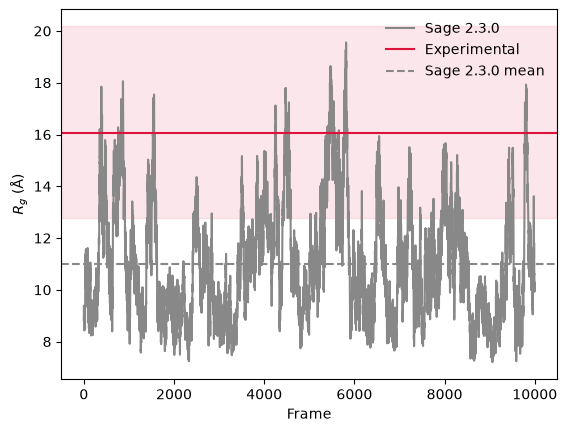

In [29]:
import numpy as np
from matplotlib import pyplot as plt

# simulation Rg
u = mda.Universe(
    "artifacts/cached_md/explicit_baseline_top.pdb",
    "artifacts/cached_md/explicit_baseline_traj.dcd"
)
peg_atoms = u.select_atoms("resname CPL OCC CPR")
rg_all_frames = np.array([peg_atoms.radius_of_gyration() for _ in u.trajectory])
n_frames = np.arange(len(rg_all_frames))

# experimental Rg
MW = sum(atom.mass for atom in peg.atoms).m_as("dalton")
# Devanand-Selser Rg (Å); Part 2.5 uses this same prefactor /10 for nm.
rg_expt = 0.215 * MW ** 0.583
rg_expt_low = 0.215 * MW ** (0.583 - 0.031)
rg_expt_high = 0.215 * MW ** (0.583 + 0.031)

# plot
fig, ax = plt.subplots(dpi=300)
ax.plot(n_frames, rg_all_frames, color=FF_COLORS["baseline"], label="Sage 2.3.0")
ax.axhspan(rg_expt_low, rg_expt_high, color="crimson", alpha=0.1, zorder=-1)
ax.axhline(rg_expt, color="crimson", label="Experimental")
ax.axhline(rg_all_frames.mean(), color=FF_COLORS["baseline"], linestyle="--", label="Sage 2.3.0 mean")
ax.set_xlabel("Frame")
ax.set_ylabel("$R_g$ (Å)")
plt.legend()

As you can see the simulated radius of gyration is a fair bit lower than that indicated by experiment, even with the error included. This may be due to a number of factors; one such may be deficiencies in the force field used to simulate.

# Part 2: Fitting a force field

Sage 2.3.0 is a good general force field, but general force fields are sometimes
not perfectly suited towards specific chemistries. As a demonstration here of
how you could either make use of our machinery to fit a better general force field
or even a bespoke one tailored to your system of interest, we walk through some example fits below.


* **Fit 1 — DFT.** Download a purpose-built QCArchive torsiondrive set
  computed at B3LYP-D3BJ/DZVP, and fit with `descent`.
* **(Optional) Fit 2 — Egret-1 (S2.3).** Take the identical torsiondrive geometries and
  recompute energies + forces with the Egret-1 potential, then fit with the *same* code.
  This is a quick-and-dirty demonstration of the effects of using a different level of theory
  as a reference.
* **(Optional) Fit 3 — PRESTO.** A bespoke, all-valence force field trained with
  `presto` against the same Egret-1 potential, directly on the held-out
  molecules.


<div style="background:#e7f3fe; border-left:6px solid #2196F3; color:#1a1a1a; padding:12px 16px; margin:8px 0; border-radius:4px;">
<b>📘 Note:</b> To keep this demo simple and easy we choose to fit only torsion force constants
and to a very small dataset comprising only PEG-related torsiondrives. In a real
fit, you will most likely want to fit other terms in the force field, and to both
a larger and more diverse dataset, both chemically and in training target types.
</div>

## 2.1: Obtaining the training data (optional to run)

Before fitting we need reference and validation data. In practice, the training dataset
should likely comprise a mix of optimized geometries (constrained or otherwise)
and single point calculations at non-optimized points to fit forces properly.
However, for the purposes of this demo we only use a set of torsiondrives.
In a torsion drive, we rotate a conformer geometry around a central bond
to evaluate the torsion energy profile. This is a constrained optimization
as the dihedral angle is constrained but the remainder of the molecule is
free to relax.



In the cells below we:

- download a DFT set of torsiondrives from QCArchive. We have a number of other datasets freely available!
- relabel these geometries using the Egret-1 potential for the optional demo
- reshape both into a Huggingface dataset formatted for `descent`.

<div style="background:#e7f3fe; border-left:6px solid #2196F3; color:#1a1a1a; padding:12px 16px; margin:8px 0; border-radius:4px;">
<b>📘 Note:</b> This step can take a while (especially downloading and relabelling),
so we've shipped the pre-formatted dataset in the workshop.
The cells below are for illustrative purposes only, we don't recommend trying
to rerun it live. Feel free to just skip past these.
</div>


### 2.1.1: download the DFT torsiondrives from QCArchive

The DFT reference is the public `OpenFF PEG Ether Fragments TorsionDrives
v4.0` dataset. We open a `qcportal` client,
pull the torsiondrive dataset, and for each record take the final single point
of every constrained optimisation along the scan and convert units: geometry, energy,
and gradient converts to the workshop's (Å, kcal/mol, forces = −gradient). 

In [30]:
import pandas as pd
import qcportal as ptl

def download_from_qca(output_file):
    """Save per-grid-point torsiondrive data to the output parquet (so we can plot the
    energy profiles later). Multiple conformers per SMILES -> relative energies."""

    # download the dataset
    client = ptl.PortalClient("https://api.qcarchive.molssi.org:443/")
    ds = client.get_dataset("torsiondrive", "OpenFF PEG Ether Fragments TorsionDrives v4.0")
    print(f"QCArchive dataset: {len(ds.entry_names)} torsiondrives")

    # convert the dataset
    rows = []
    # this can be slow as each request fetches additional information from the server
    for ename in tqdm.tqdm(ds.entry_names, desc="Parsing each record"):
        entry, rec = ds.get_entry(ename), ds.get_record(ename, "default")
        if "complete" not in str(rec.status).lower():
            continue
        cmiles = entry.attributes["canonical_isomeric_explicit_hydrogen_mapped_smiles"]
        dihedral = rec.specification.keywords.dihedrals[0]
        for scan_idx, (gid, opt) in enumerate(
                sorted(rec.minimum_optimizations.items(), key=lambda kv: kv[0][0])
        ):
            final = opt.trajectory[-1]
            conformer = unit.Quantity(np.asarray(opt.final_molecule.geometry), "bohr")
            energy = unit.Quantity(final.properties["return_energy"], "hartree") * unit.avogadro_constant
            gradient = np.asarray(final.properties["return_gradient"]).reshape(-1, 3)
            gradient_units = unit.Quantity(gradient, "hartree/bohr") * unit.avogadro_constant
            rows.append({
                "torsiondrive_id": str(rec.id),
                "smiles": cmiles,
                "torsion_indices": [int(i) for i in dihedral],
                "scan_idx": scan_idx,
                "angle": float(gid[0]),
                "energy": float(energy.m_as("kilocalorie/mole")),
                "atomic_numbers": [int(z) for z in np.asarray(opt.final_molecule.atomic_numbers)],
                "coords": conformer.m_as("angstrom").tolist(),
                "forces": (-gradient_units.m_as("kilocalorie/mole/angstrom")).tolist(),
            })

    qca_df = pd.DataFrame(rows)
    output_file = pathlib.Path(output_file)
    output_file.parent.mkdir(parents=True, exist_ok=True)
    qca_df.to_parquet(output_file, index=False)

In [31]:
# Set DOWNLOAD_QCA = True to re-fetch from QCArchive (may take a few min)
DOWNLOAD_QCA = False
QCA_PARQUET = DATA / "qca_peg_td" / "qca_peg_scans.parquet"

if DOWNLOAD_QCA or not QCA_PARQUET.exists():
    download_from_qca(QCA_PARQUET)

QCArchive dataset: 50 torsiondrives


Parsing each record: 100%|██████████████████████████████████████████████████████████████████████████| 50/50 [32:56<00:00, 39.53s/it]


### 2.1.2 (optional): relabel the same geometries with Egret-1

For a quick demonstration of the effect of changing the reference,
we can also recompute each snapshot from the DFT using the Egret-1 MACE potential.
Note that there's no re-optimisation here; this is a quick and dirty substitute.

Again, this can take several minutes to compute and we would recommend
loading the cached data for file; the code below is simply provided for
provenance and for interest.

In [32]:
def recompute_with_egret(qca_file, output_file):
    import presto
    from ase import Atoms
    from mace.calculators import MACECalculator
    from openff.units import unit

    EV_TO_KCAL = (1.0 * unit.elementary_charge * unit.volt
                  * unit.avogadro_constant).m_as(unit.kilocalorie / unit.mole)
    model = pathlib.Path(presto.__file__).parent / "models" / "EGRET_1.model"
    calc = MACECalculator(model_paths=str(model), device="cpu", default_dtype="float64")

    df = pd.read_parquet(qca_file)   # the SAME DFT geometries
    energies, forces = [], []
    for _, row in tqdm.tqdm(df.iterrows(), desc="Relabelling", total=len(df)):
        atoms = Atoms(
            numbers=list(row["atomic_numbers"]),
            positions=np.stack(row["coords"]),   # coords is an object array of (3,) per-atom arrays
        )
        atoms.calc = calc
        energies.append(float(atoms.get_potential_energy() * EV_TO_KCAL))
        forces.append((atoms.get_forces() * EV_TO_KCAL).tolist())
    out = df.copy()
    out["energy"] = energies
    out["forces"] = forces

    output_file = pathlib.Path(output_file)
    output_file.parent.mkdir(parents=True, exist_ok=True)
    out.to_parquet(output_file, index=False)
    return out

In [33]:
RELABEL_EGRET = False   # True to recompute Egret-1 labels from the QCA geometries (slow on CPU)
MLIP_PARQUET = DATA / "mlip_peg_td" / "mlip_peg_scans.parquet"

if RELABEL_EGRET or not MLIP_PARQUET.exists():
    recompute_with_egret(QCA_PARQUET, MLIP_PARQUET)

/Users/lily/pydev/workshops/2026-polymers/.pixi/envs/default/lib/python3.12/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))
/Users/lily/pydev/workshops/2026-polymers/.pixi/envs/default/lib/python3.12/site-packages/mace/calculators/mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
/Users/lily/pydev/workshops/2026-polymers/.pixi/envs/default/lib/python3.12/site-packages/mace/calculators/mace.py:226: UserWarning: 'torch.load' received a zip file that looks like a TorchScript archive dispatching to 'torch.jit.load' (call 'torch.jit.loa

cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.


Relabelling: 100%|██████████████████████████████████████████████████████████████████████████████| 1200/1200 [08:08<00:00,  2.46it/s]


### 2.1.3: splitting training and test sets

We hold out **5 torsiondrives**, chosen once (diverse
MaxMin pick, seed 42) and recorded in `data/split.json`.
We use the torsiondrive ID to distinguish so we can benchmark
on the same torsiondrives even with different reference levels,
and plot the torsiondrives later.

<div style="background:#fff8e1; border-left:6px solid #ffc107; color:#1a1a1a; padding:12px 16px; margin:8px 0; border-radius:4px;">
<b>⚠️  Warning:</b> Of course, 5 torsiondrives is a really small test set,
    and 45 training torsiondrives is also very small! Demo purposes only.
</div>

In [34]:
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
from rdkit.SimDivFilters.rdSimDivPickers import MaxMinPicker

def select_test_set(scans_df, n_test: int = 5):
    df = scans_df.sort_values("torsiondrive_id")

    # generate Morgan fingerprints
    fpg = rdFingerprintGenerator.GetMorganGenerator(radius=3)
    fps = [fpg.GetFingerprint(Chem.MolFromSmiles(s)) for s in df["smiles"]]
    
    # the LazyBitVectorPick automatically uses Tanimoto distance as metric
    # or you can pass in a distFunc to LazyPick if you want
    picks = MaxMinPicker().LazyBitVectorPick(fps, len(fps), n_test, seed=42)

    tids = list(df["torsiondrive_id"])
    test_ids = [tids[i] for i in picks]
    tid_to_smiles = dict(zip(df["torsiondrive_id"], df["smiles"]))
    return {
        "dataset": "OpenFF PEG Ether Fragments TorsionDrives v4.0",
        "n_test": n_test,
        "seed": 42,
        "test_torsiondrive_ids": test_ids,
        "test_smiles": [tid_to_smiles[i] for i in test_ids],
    }

Below we save these to file.

In [35]:
import json

json_file = DATA / "split.json"
MAKE_SPLIT = False   # regenerate the shared train/test split (else load cached split.json)
if MAKE_SPLIT or not json_file.exists():
    dft_pq = pd.read_parquet("data/qca_peg_td/qca_peg_scans.parquet")
    split = select_test_set(dft_pq)
    json_file.write_text(json.dumps(split))
    print(f"Selected {split['n_test']} torsiondrives to test on")
else:
    split = json.loads(json_file.read_text())

test_smiles = split["test_smiles"]
print(f"Our test smiles: {test_smiles}")

Selected 5 torsiondrives to test on
Our test smiles: ['[C:1]([C:2]([O:3][C:4]([C:5]([O:6][C:7]([C:8]([O:9][H:23])([H:21])[H:22])([H:19])[H:20])([H:17])[H:18])([H:15])[H:16])([H:13])[H:14])([H:10])([H:11])[H:12]', '[C:1]([O:2][C:3]([C:4]([C:5]([H:19])([H:20])[H:21])([O:6][C:7]([C:8]([O:9][C:10]([C:11]([H:27])([H:28])[H:29])([C:12]([H:30])([H:31])[H:32])[H:26])([H:24])[H:25])([H:22])[H:23])[H:18])([H:16])[H:17])([H:13])([H:14])[H:15]', '[O:1]([C:2]([C:3]([O:4][H:10])([H:8])[H:9])([H:6])[H:7])[H:5]', '[C:1]([O:2][C:3]([C:4]([O:5][C:6]([H:14])([H:15])[H:16])([H:12])[H:13])([H:10])[H:11])([H:7])([H:8])[H:9]', '[C:1]([C:2]([C:3]([O:4][H:15])([H:13])[H:14])([O:5][C:6]([C:7]([O:8][H:20])([H:18])[H:19])([H:16])[H:17])[H:12])([H:9])([H:10])[H:11]']


And we can visualize below...

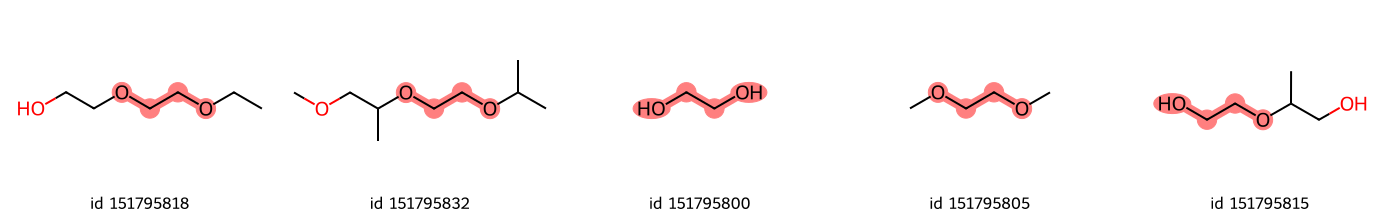

In [36]:
from peg_workshop_utils import draw_torsions_by_id

# Draw the held-out torsiondrives with their driven O-C-C-O torsion highlighted.
dft_pq = pd.read_parquet("data/qca_peg_td/qca_peg_scans.parquet")
draw_torsions_by_id(dft_pq, split["test_torsiondrive_ids"])

### 2.1.4: converting to `descent` dataset format

`descent` requires a HuggingFace table with one row per molecule. The columns required are:

- `smiles`: a string of atom-mapped SMILES (so coordinates can be mapped correctly)
- `coords`: an array of `(n_conf, n_atoms, 3)` in Å
- `energy`: an array of `(n_conf,)` in kcal/mol
- `forces`: an array of `(n_conf, n_atoms, 3)` in kcal/mol/Å.

For a torsiondrive, entry the "conformers" are the grid points along the dihedral. For descent,
each molecule should contain multiple conformers, as `descent` fits **relative** energies.

In [37]:
def build_descent_dataset(scans_df, out_dir):
    """Convert the high-info parquet to just what descent needs (one entry per torsiondrive)."""
    import descent.targets.energy
    entries = []
    for tid, g in scans_df.groupby("torsiondrive_id", sort=False):
        g = g.sort_values("scan_idx")
        e = np.asarray(g["energy"].tolist(), dtype=np.float64)
        if e.shape[0] < 2:
            continue
        entries.append(
            descent.targets.energy.Entry(
                smiles=g["smiles"].iloc[0],
                coords=np.array([np.stack(x) for x in g["coords"]], dtype=np.float64),
                energy=e,
                forces=np.array([np.stack(x) for x in g["forces"]], dtype=np.float64),
            )
        )
    out_dir = pathlib.Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    descent.targets.energy.create_dataset(entries).save_to_disk(str(out_dir))
    return len(entries)

In [38]:
from datasets import load_from_disk

# Hold-out is keyed on torsiondrive_id (split.json is the source of truth), so we
# split the parquet first, then build a descent dataset for each side.
test_ids = set(split["test_torsiondrive_ids"])

def split_and_build(scans_df, base):
    base = pathlib.Path(base)
    train_dir, test_dir = base.with_name(base.name + "_train"), base.with_name(base.name + "_test")
    if not (train_dir.exists() and test_dir.exists()):
        is_test = scans_df["torsiondrive_id"].isin(test_ids)
        build_descent_dataset(scans_df[~is_test], train_dir)
        build_descent_dataset(scans_df[is_test], test_dir)
    return load_from_disk(str(train_dir)), load_from_disk(str(test_dir))

dft_pq = pd.read_parquet("data/qca_peg_td/qca_peg_scans.parquet")
egret_pq = pd.read_parquet("data/mlip_peg_td/mlip_peg_scans.parquet")
dft_train, dft_test = split_and_build(dft_pq, "data/qca_peg_td/descent_dataset")
egret_train, egret_test = split_and_build(egret_pq, "data/mlip_peg_td/descent_dataset")

## 2.2: Fitting force fields with smee + descent

Now that we have our datasets and train/test split, we can move forward with the fitting pipeline.

This is a new fitting stack that OpenFF is aiming to transition all our force field fits to during this roadmap year. `descent` fits force fields using PyTorch as its computational backend.

<div style="background:#e7f3fe; border-left:6px solid #2196F3; color:#1a1a1a; padding:12px 16px; margin:8px 0; border-radius:4px;">
<b>📘 New to PyTorch?</b> PyTorch's `Tensor` behaves like a NumPy array, but supports automatic differentiation: any computation built from tensors can be differentiated with respect to its inputs automatically. `smee` writes the force field energy (and force) evaluation entirely in PyTorch, with the parameters you want to fit (e.g. torsion force constants) marked `requires_grad=True`. That means the gradient of the loss — how far off the model's energies/forces are from the reference data — with respect to every trainable parameter comes for free via backpropagation (`loss.backward()`), with no analytic derivatives to hand-derive. It's the same machinery used to train neural networks, just applied to physically-motivated force field parameters instead of network weights. Today's fit is tiny and runs fine on CPU, but the same code scales to a GPU for larger fits.
</div>

In [39]:
import torch
import descent.targets.energy
import descent.train
from peg_workshop_utils import write_smirnoff
import datasets
import smee

### 2.2.1: Converting force fields and molecules from OpenFF to PyTorch via smee

We can convert the OpenFF objects to PyTorch via smee, as demonstrated below in `build_tensor_ff`. Given the baseline
SMIRNOFF force field and a set of atom-mapped SMILES, it parameterises every
molecule with that force field and uses `smee` to convert the result into a
single `smee.TensorForceField` (the force-field parameters as differentiable
PyTorch tensors) plus a dict mapping each SMILES to its `smee.TensorTopology`.
We build it over the union of train + test SMILES so the fitted parameters
can be evaluated on the held-out molecules without rebuilding.

In [40]:
import smee.converters

def build_tensor_ff(
    init_ff: ForceField,
    smiles_iter: list[str]
) -> tuple[smee.TensorForceField, dict[str, smee.TensorTopology]]:
    """One smee TensorForceField + per-SMILES TensorTopology over a set of SMILES.

    Built over the UNION of train + test SMILES so the fitted params can be
    evaluated on the held-out set without re-converting.
    """
    smiles_list = sorted(set(smiles_iter))
    mols = [
        Molecule.from_mapped_smiles(s, allow_undefined_stereo=True)
        for s in smiles_list
    ]
    
    # create interchanges
    interchanges = [init_ff.create_interchange(m.to_topology()) for m in mols]
    tensor_ff, tensor_tops = smee.converters.convert_interchange(interchanges)
    return tensor_ff, dict(zip(smiles_list, tensor_tops))

### 2.2.2: Specifying loss functions

Zooming out, the fitting loop looks like this: reference data (QM or MLIP
energies/forces) → predicted MM energies/forces from the current `smee` force field
→ a weighted loss comparing the two → gradients w.r.t. the trainable SMIRNOFF
parameters (via PyTorch autodiff, see above) → an optimizer step that updates those
parameters → repeat. At the end, the updated tensor force field is written back out
to a fresh `.offxml`. We fit **relative** energies per torsiondrive (not absolute),
since only relative conformer energies are physically meaningful for a fixed molecule;
forces are weighted much less than energies here (see `energy_weight`/`force_weight`
below), since energies are the primary fitting target for this demo.

Once everything is a smee/PyTorch object, we can look at fitting.
First, let's define some loss functions. We keep this out of the training loop just for convenience, as we want to compute the loss for both the training set and the test set.

In [41]:
def compute_dataset_loss(
    # the transformation of a OpenFF force field into a PyTorch object
    forcefield: smee.TensorForceField,
    dataset: datasets.Dataset,
    # transformation of an Interchange into a PyTorch object
    topologies: dict[str, smee.TensorTopology],
    energy_weight: float, # energy loss weighting
    force_weight: float, # force loss weight
) -> torch.Tensor:
    # compute energy/force losses
    e_ref, e_pred, f_ref, f_pred = descent.targets.energy.predict(
        dataset, forcefield, topologies, "mean"
    )
    e_mse = ((e_pred - e_ref) ** 2).mean()
    f_mse = ((f_pred - f_ref) ** 2).mean()
    loss = (e_mse * energy_weight) + (f_mse * force_weight)
    return loss

### 2.2.3: Defining what to train

Then we can look at what we want to train. ``descent`` allows you to train any parameter or attribute supported in canonical SMIRNOFF force fields. In short, a 'parameter' is something that may vary based on SMIRKS or chemistry -- for example, the force constants of a proper torsion, or the equilibrium value of a bond. An 'attribute' is something that applies across the entire force field, such as the scaling factor for 1-4 interactions.

For today's demo, we restrict ourselves to just training the force constants (`k`) of proper dihedrals. Typically in a valence fit we would want to train the force constants and equilibrium values of all bonds, angles, and torsions, but we want to keep today's example small.

In [42]:
# Default trainable set: ProperTorsions.k only.
torsion_training_config = {
    "ProperTorsions": descent.train.ParameterConfig(
        cols=["k"],
        scales={"k": 1.0},
        # uncomment if you want to limit force constants to 0
        # this is useful for bond and angles,
        # but not so much for torsions, where negative force constants are fine
        # limits={"k": [0.0, None]},
    ),
}

### 2.2.4: Setting up the optimization loop

Then let's set up the fit. We'll do the training inside a `run_fit` function so we can easily swap out different training sources later in the notebook.

Each line in this function is commented, but in short, `run_fit` takes a training and testing dataset of energies and forces, the smee representations of the molecules in those datasets, and trains an already converted smee ForceField according to given parameter configs, particular weightings of energies, number of epochs, and so on.

In [43]:
def run_fit(
    train_dataset: datasets.Dataset,
    train_topologies: dict[str, smee.TensorTopology],
    test_dataset: datasets.Dataset,
    test_topologies: dict[str, smee.TensorTopology],
    tensor_ff: smee.TensorForceField,
    parameters_config: dict[str, descent.train.ParameterConfig],
    output_file: str,
    energy_weight: float = 10,
    force_weight: float = 1,
    n_epochs: int = 1000,
    lr: float = 1e-2,
    log_every: int = 10,
) -> np.ndarray:
    """Adam loop over the trainable params against a weighted, normalised L2 loss."""
    
    # Trainable wraps the tensor FF and exposes ONLY the parameters named in
    # parameters_config as a single flat, differentiable torch vector.
    trainable = descent.train.Trainable(
        force_field=tensor_ff,
        parameters=parameters_config,
        # if we wanted to train any 'attributes', e.g. 1-4 scaling factors,
        # they would go here.
        attributes={}
    )
    params = trainable.to_values()  # the (requires_grad) vector that the optimiser updates

    # set up the optimizer
    optimizer = torch.optim.Adam([params], lr=lr, amsgrad=True)
    history = []
    for epoch in tqdm.tqdm(range(n_epochs), desc="training"):
        # Rebuild a tensor FF from the current params
        ff = trainable.to_force_field(params)

        train_loss = compute_dataset_loss(
            ff, train_dataset, train_topologies,
            energy_weight, force_weight
        )
        
        # clear params.grad to avoid accumulation
        optimizer.zero_grad()
        # backprop: fill params.grad = d(train_loss)/d(params)
        train_loss.backward()
        # Adam update of params using params.grad
        optimizer.step()

        if epoch % log_every == 0 or epoch == n_epochs - 1:
            # save train and test loss for plotting
            test_loss = compute_dataset_loss(
                ff, test_dataset, test_topologies,
                energy_weight, force_weight
            )
            history.append([epoch, train_loss.detach().item(), test_loss.detach().item()])

    # convert the trained smee force field back to offxml format
    fitted_ff = write_smirnoff(
        init_ff,
        trainable.to_force_field(params),
        parameters_config
    )
    fitted_ff.to_file(output_file)
    # return our history of losses
    return np.array(history)

## Fit 1: DFT (QCArchive torsiondrives)

Now let's try running it on data! For our first fit, our training set is the downloaded QCArchive torsiondrive set: 45 PEG
ether-fragment O–C–C–O scans at B3LYP-D3BJ/DZVP.

In [44]:
# load initial FF
initial_ff = ForceField("openff-2.3.0.offxml")

In [45]:
# load data (if not done above)
from datasets import load_from_disk

dft_pq = pd.read_parquet("data/qca_peg_td/qca_peg_scans.parquet")
dft_train = load_from_disk("data/qca_peg_td/descent_dataset_train")
dft_test = load_from_disk("data/qca_peg_td/descent_dataset_test")

In [46]:
# build the smee objects for force fields and topologies (over all molecules)
dft_tensor_ff, dft_tops_all = build_tensor_ff(initial_ff, dft_pq["smiles"].unique())
dft_train_topologies = {s: dft_tops_all[s] for s in dft_train["smiles"]}
dft_test_topologies = {s: dft_tops_all[s] for s in dft_test["smiles"]}

In [47]:
# run the fit and save it to this file
hist_dft = run_fit(
    dft_train,
    dft_train_topologies,
    dft_test,
    dft_test_topologies,
    dft_tensor_ff,
    torsion_training_config,
    "artifacts/peg_fitted_dft_live.offxml", # output file
    # constrained-optimisation forces are tiny, so weight energies higher
    energy_weight=10,
    force_weight=1,
    n_epochs=600,
    lr=1e-3,
    log_every=10,
)

training: 100%|███████████████████████████████████████████████████████████████████████████████████| 600/600 [03:00<00:00,  3.33it/s]


## 2.3 Fit 2 (optional): Egret-1, a MACE potential

Now we can run the exact same fit again, swapping out the train/test dataset, to see what effect that might have on the fit.

In [48]:
# load new data
egret_pq = pd.read_parquet("data/mlip_peg_td/mlip_peg_scans.parquet")
egret_train = load_from_disk("data/mlip_peg_td/descent_dataset_train")
egret_test = load_from_disk("data/mlip_peg_td/descent_dataset_test")

# build smee objects too
egret_tensor_ff, egret_tops_all = build_tensor_ff(initial_ff, egret_pq["smiles"].unique())
egret_train_topologies = {s: egret_tops_all[s] for s in egret_train["smiles"]}
egret_test_topologies = {s: egret_tops_all[s] for s in egret_test["smiles"]}

# rerun fit with new dataset
offxml_egret = ART / "peg_fitted_egret_live.offxml"
hist_egret = run_fit(
    egret_train,
    egret_train_topologies,
    egret_test,
    egret_test_topologies,
    egret_tensor_ff,
    torsion_training_config,
    "artifacts/peg_fitted_egret_live.offxml",
    energy_weight=10,
    force_weight=1,
    n_epochs=600,
    lr=1e-3,
    log_every=10,
)

training: 100%|███████████████████████████████████████████████████████████████████████████████████| 600/600 [02:53<00:00,  3.46it/s]


Text(0, 0.5, 'Weighted L2 loss')

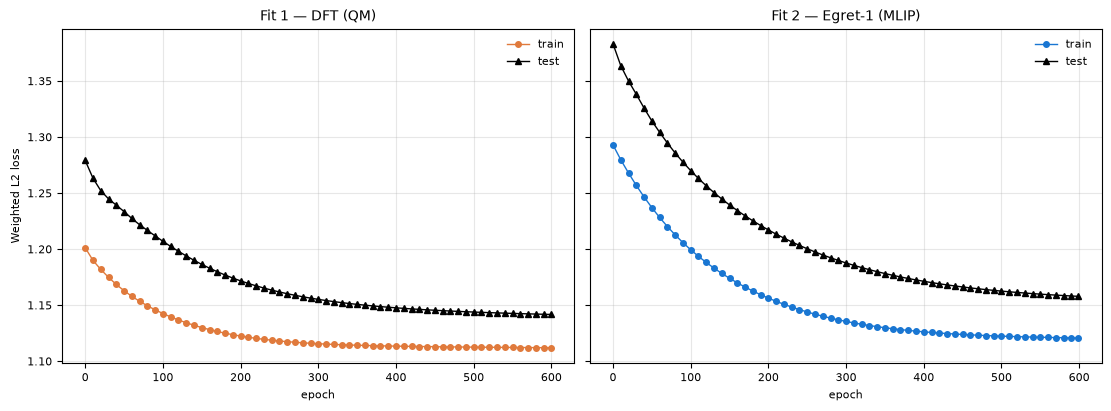

In [49]:
# Side-by-side loss histories
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True, constrained_layout=True, dpi=300)
for ax, hist, title, color in [
    (axes[0], hist_dft,   "Fit 1 — DFT (QM)",   FF_COLORS["dft"]),
    (axes[1], hist_egret, "Fit 2 — Egret-1 (MLIP)", FF_COLORS["egret"]),
]:
    ax.plot(hist[:, 0], hist[:, 1], "-o", color=color, lw=1, ms=4, label="train")
    ax.plot(hist[:, 0], hist[:, 2], "-^", color="black", lw=1, ms=4, label="test")
    ax.set_xlabel("epoch")
    ax.set_title(title, fontsize=10)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
axes[0].set_ylabel("Weighted L2 loss")

<div style="background:#e8f5e9; border-left:6px solid #43a047; color:#1a1a1a; padding:12px 16px; margin:8px 0; border-radius:4px;">
<b>✏️ Exercise:</b> Try rerunning one of these fits with bonds, angles, and torsions all trained. What do you see?
</div>

In [51]:
# example config: bonds + angles + torsions.
bat_training_config = {
    "Bonds": descent.train.ParameterConfig(
        cols=["k", "length"], scales={"k": 1.0e-2, "length": 1.0},
        limits={"k": [0.0, None], "length": [0.0, None]},
    ),
    "Angles": descent.train.ParameterConfig(
        cols=["k", "angle"], scales={"k": 1.0e-2, "angle": 1.0e-2},
        limits={"k": [0.0, None], "angle": [0.0, np.pi]},
    ),
    "ProperTorsions": descent.train.ParameterConfig(
        cols=["k"], scales={"k": 1.0},
    ),
}

### Fit 3 (optional): PRESTO for bespoke force fields

Above, we experimented with just fitting the torsion force constants of a general small molecule force field,
to a small human-generated dataset at different reference levels of theory.


[**PRESTO**](https://cole-group.github.io/presto/latest/) takes a different approach:
rather than refit a fixed parameter list against pre-computed labels, it
generates its own training data by sampling each molecule with an MLP, and
fits the full valence parameter set (bonds, angles, propers, impropers) with
bespoke SMIRKS per molecule. As the backend here we use Egret-1 potential used
for Fit 2 for more direct comparison, although PRESTO supports a number of different MLIPs.

As PRESTO is intended for bespoke force fields, we train on the test set
as an example of intended use.

<div style="background:#fff8e1; border-left:6px solid #ffc107; color:#1a1a1a; padding:12px 16px; margin:8px 0; border-radius:4px;">
<b>⚠️ Note:</b> PRESTO can technically run without CUDA, but it will be incredibly slow.
We have provided a PRESTO force field fit properly on a CUDA machine
in artifacts/ , and the script train_presto.py for reference.
The code below is just an example and took me ~80 min to run on my laptop.
</div>


In [61]:
# Slimmed-down demo of the PRESTO workflow

def run_presto(output_file):
    from presto.settings import (
        MLMDSamplingSettings,
        MLPSettings,
        MMMDMetadynamicsTorsionMinimisationSamplingSettings,
        MSMSettings,
        ParamSettings,
        WorkflowSettings,
    )
    from presto.workflow import get_bespoke_force_field

    # load test molecules
    molecules = [
        Molecule.from_mapped_smiles(c, allow_undefined_stereo=True).to_smiles(mapped=False)
        for c in split["test_smiles"]
    ]
    # load mlp
    egret = MLPSettings(ml_potential="egret-1")
    
    # Trimmed sampling so the demo finishes in minutes (vs PRESTO's 10x100 ps default).
    train_sampling = MMMDMetadynamicsTorsionMinimisationSamplingSettings(
        mlp_settings=egret,
        n_conformers=2,
        production_sampling_time_per_conformer=5 * ommunit.picoseconds,
        snapshot_interval=1 * ommunit.picoseconds,
        bias_save_frequency=1 * ommunit.picoseconds,
    )
    test_sampling = MLMDSamplingSettings(
        mlp_settings=egret, n_conformers=2,
        production_sampling_time_per_conformer=2 * ommunit.picoseconds,
        snapshot_interval=0.1 * ommunit.picoseconds,
    )
    settings = WorkflowSettings(
        param_settings=ParamSettings(
            molecule_input_type="smiles", molecules=molecules,
            msm_settings=MSMSettings(mlp_settings=egret),
        ),
        device_type="cpu", # this is very slow! swap to cuda for proper runs
        n_iterations=1,
        training_sampling_settings=train_sampling,
        testing_sampling_settings=test_sampling,
    )
    print("Running slimmed PRESTO demo (CPU -- slow; the full fit ships as artifacts/peg_presto.offxml)...")
    pathlib.Path(output_file).parent.mkdir(parents=True, exist_ok=True)
    
    bespoke_ff = get_bespoke_force_field(settings)
    bespoke_ff.to_file(str(output_file))

In [54]:
RUN_PRESTO_LIVE = False   # CPU PRESTO is very slow; the full fit ships as artifacts/peg_presto.offxml
if RUN_PRESTO_LIVE:
    run_presto("artifacts/peg_presto_demo.offxml")   # demo output; does not overwrite the shipped artifact

/Users/lily/pydev/workshops/2026-polymers/.pixi/envs/default/lib/python3.12/site-packages/pydantic/main.py:253: UserWarning: Using CPU for training and sampling. This may be slow. Consider using CUDA if available.
  validated_self = self.__pydantic_validator__.validate_python(data, self_instance=self)
2026-07-02 01:13:50.094 | INFO     | presto.workflow:get_bespoke_force_field:68 - Writing workflow settings to workflow_settings.yaml.
2026-07-02 01:13:50.293 | INFO     | presto.create_types:add_types_to_forcefield:297 - Generated 67 bespoke SMARTS patterns for handler Bonds across 5 molecules.


Running slimmed PRESTO demo (CPU -- slow; the full fit ships as artifacts/peg_presto.offxml)...


2026-07-02 01:13:50.334 | INFO     | presto.create_types:add_types_to_forcefield:297 - Generated 111 bespoke SMARTS patterns for handler Angles across 5 molecules.
2026-07-02 01:13:50.402 | INFO     | presto.create_types:add_types_to_forcefield:297 - Generated 94 bespoke SMARTS patterns for handler ProperTorsions across 5 molecules.
2026-07-02 01:13:50.469 | INFO     | presto.create_types:add_types_to_forcefield:297 - Generated 0 bespoke SMARTS patterns for handler ImproperTorsions across 5 molecules.
2026-07-02 01:13:51.174 | DEBUG    | presto.create_types:_remove_redundant_smarts:187 - Removed unused parameter b-bespoke-109 with SMIRKS [H:1]-[#6&!H0&!H1:2]-[#8]-[#6&!H0&!H1]-[#6&!H0](-[#8]-[#6&!H0&!H1]-[#6&!H0&!H1]-[#8]-[#6&!H0](-[#6&!H0&!H1&!H2])-[#6&!H0&!H1&!H2])-[#6&!H0&!H1&!H2] from Bonds
2026-07-02 01:13:51.175 | DEBUG    | presto.create_types:_remove_redundant_smarts:187 - Removed unused parameter b-bespoke-125 with SMIRKS [#6&!H0&!H1&!H2]-[#8]-[#6&!H0&!H1]-[#6&!H0](-[#8]-[#6&!H

Output()

/Users/lily/pydev/workshops/2026-polymers/.pixi/envs/default/lib/python3.12/site-packages/openmmml/models/macepoten
tial.py:173: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` 
argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  model = torch.load(self.modelPath, map_location=device).to(device)

...

Output()

2026-07-02 02:32:31.521 | INFO     | presto.analyse:plot_all_ffs:539 - Plotting force field values with 4 rows and 4 columns


Output()

2026-07-02 02:32:33.517 | INFO     | presto.analyse:plot_all_ffs:539 - Plotting force field differences with 4 rows and 4 columns


Output()

## 2.4: Cross-benchmark the fits on QM data

Now let's compare how each FF does on the test set of torsiondrives at different levels of theory.

In [55]:
from peg_workshop_utils import evaluate_on_parquet

def aggregate_rmse(rows):
    return float(np.mean([r["rmse"] for r in rows if r["is_test"]]))

# map force fields to labels
fit_ffs = {
    "baseline (Sage 2.3.0)": init_ff,
    "fit: DFT (QCArchive)":  ForceField("artifacts/peg_fitted_dft_live.offxml"),
    "fit: Egret-1 (MLIP)":   ForceField("artifacts/peg_fitted_egret_live.offxml"),
    "fit: PRESTO (fit to test set)": ForceField("artifacts/peg_presto.offxml")
}

test_ids = set(split["test_torsiondrive_ids"])
test_sets = {
    "DFT test (B3LYP)":    (dft_pq, test_ids),
    "Egret-1 test (MLIP)": (egret_pq, test_ids),
}

# evaluate over a loop and save
xval_cache, matrix = {}, {}
for ff_label, ff in tqdm.tqdm(fit_ffs.items(), desc="Evaluating"):
    for test_label, (pq, ts) in test_sets.items():
        rows = evaluate_on_parquet(ff, pq, ts)
        xval_cache[(ff_label, test_label)] = rows
        matrix[(ff_label, test_label)] = aggregate_rmse(rows)

Evaluating: 100%|█████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:43<00:00, 10.88s/it]


First let's have a look at the actual torsion scans. The refits generally move the
torsion profiles toward their chosen reference; the cross-benchmark below shows
whether that improvement transfers across reference levels and to the held-out
(test) torsiondrives, or is specific to what each fit was trained on.

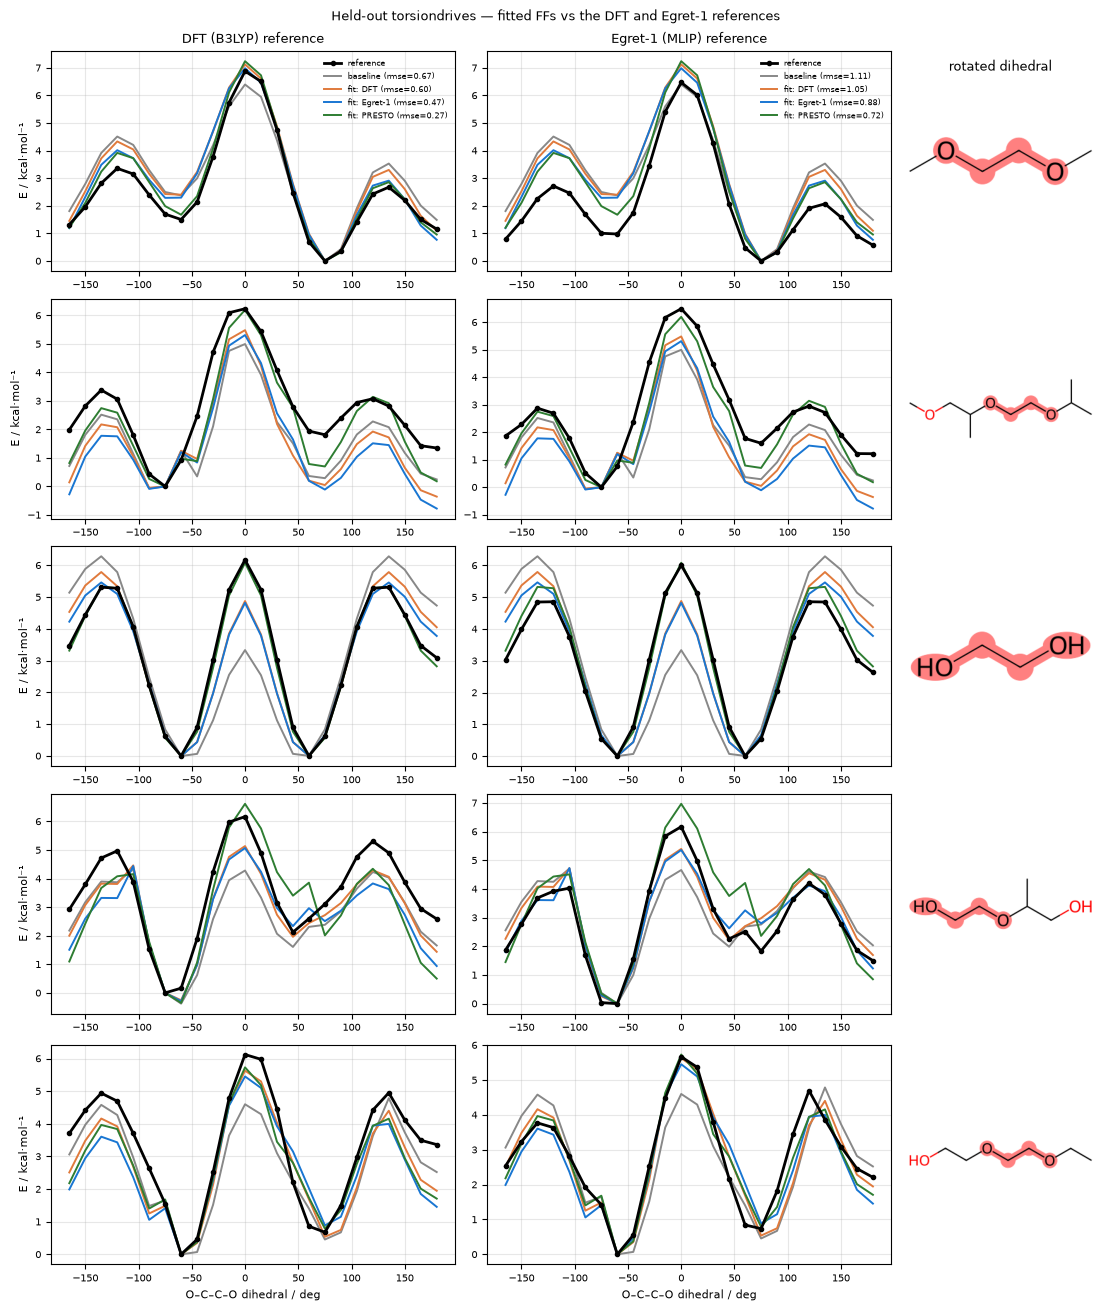

In [56]:
from peg_workshop_utils import draw_dihedral, scan_panel

# one torsiondrive per row; columns are DFT (B3LYP), the Egret-1 (MLIP), dihedral diagram
DFT_TEST, EGRET_TEST = "DFT test (B3LYP)", "Egret-1 test (MLIP)"
ff_labels = list(fit_ffs)
ff_palette = {
    "baseline (Sage 2.3.0)": FF_COLORS["baseline"],
    "fit: DFT (QCArchive)":  FF_COLORS["dft"],
    "fit: Egret-1 (MLIP)":   FF_COLORS["egret"],
    "fit: PRESTO (fit to test set)": FF_COLORS["presto"],
}
held = [r for r in xval_cache[(ff_labels[0], DFT_TEST)] if r["is_test"]]
n_rows = len(held)

fig, axes = plt.subplots(n_rows, 3, figsize=(11, 2.6 * n_rows), squeeze=False,
                         gridspec_kw={"width_ratios": [2, 2, 1]}, constrained_layout=True,
                         dpi=300)
for i, ref in enumerate(held):
    # scan panel adds both the plots and draws the molecule
    scan_panel(
        axes[i, 0], DFT_TEST, ref["torsiondrive_id"],
        xval_cache, ff_labels, ff_palette,
        ylabel=True, legend=(i == 0)
    )
    scan_panel(
        axes[i, 1], EGRET_TEST, ref["torsiondrive_id"],
        xval_cache, ff_labels, ff_palette,
        ylabel=False, legend=(i == 0)
    )
    axes[i, 2].imshow(draw_dihedral(ref["smiles"], ref["torsion_indices"]))
    axes[i, 2].axis("off")
    

axes[-1, 0].set_xlabel("O–C–C–O dihedral / deg")
axes[-1, 1].set_xlabel("O–C–C–O dihedral / deg")
axes[0, 0].set_title("DFT (B3LYP) reference")
axes[0, 1].set_title("Egret-1 (MLIP) reference")
axes[0, 2].set_title("rotated dihedral")
fig.suptitle("Held-out torsiondrives — fitted FFs vs the DFT and Egret-1 references")
plt.show()

Or, we can plot the aggregate RMSE for an easier look.

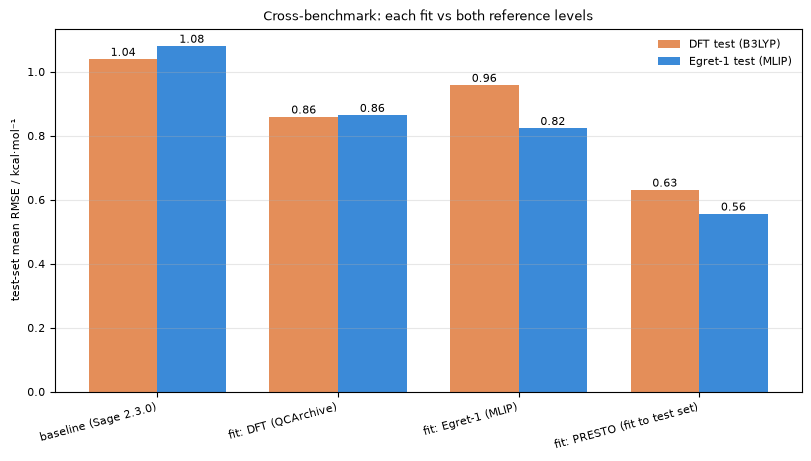

In [57]:
from peg_workshop_utils import plot_cross_benchmark

# Grouped bar plot of the cross-benchmark matrix (grouped by FF, coloured by test set).
plot_cross_benchmark(matrix, fit_ffs, test_sets, TEST_COLORS)

## 2.5: Benchmark the fits on simulation data

QM-energy RMSE (S2.4) is fast to evaluate, but typically we care more about the
performance of a force field on real simulation properties like explicit solvent $R_g$.
As it would be too difficult to simulate trajectories for any respectable length
during this workshop, we provide a 100 ns trajectory simulated in each force field.

Why would refitting a single torsion term change how compact the polymer is in
solution? PEG's radius of gyration depends strongly on which O–C–C–O dihedral
conformers (gauche vs trans) are populated along the chain, and that population is
governed by the `ProperTorsions.k` term we just fit. But $R_g$ also depends on
nonbonded/solvent interactions, sampling, and finite-size effects that a QM torsion
fit says nothing about -- so a lower QM RMSE doesn't automatically mean a better
$R_g$. That's why we check both.

Below we show the $R_g$ as computed in Part 1.

force field                    Rg (nm)
baseline (Sage 2.3.0)     1.100 ± 0.040
fit: DFT                  1.117 ± 0.030
fit: Egret-1              1.150 ± 0.046
fit: PRESTO               1.099 ± 0.045

Devanand-Selser (extrap.): 1.60 nm  (span 1.28-2.02 nm)


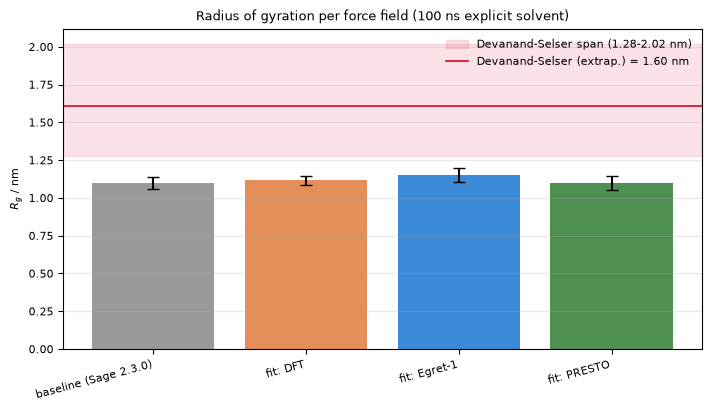

In [59]:
from peg_workshop_utils import block_average_se

# Explicit-solvent Rg per force field, from the 100 ns Iris runs in
# artifacts/md_explicit/ (one job per FF): Rg from each trajectory (PEG atoms
# selected via resname CPL/OCC/CPR, the polymer's own residues; stride 10),
# vs the Devanand-Selser experimental anchor + its span.
MD = ART / "cached_md"
STRIDE = 10

# Devanand-Selser Rg (nm); coefficient (0.0215) is the Part 1.3 Å-coefficient
# (0.215, Eq 2 in the paper) divided by 10 for nm. The span comes from the
# exponent uncertainty 0.583 +/- 0.031.
MW = sum(atom.mass for atom in peg.atoms).m_as("dalton")
rg_expt = 0.0215 * MW ** 0.583
rg_expt_low = 0.0215 * MW ** (0.583 - 0.031)
rg_expt_high = 0.0215 * MW ** (0.583 + 0.031)

LABELS = {"baseline": "baseline (Sage 2.3.0)", "dft": "fit: DFT",
          "egret": "fit: Egret-1", "presto": "fit: PRESTO"}

# calculate Rg per force field (skip any FF not simulated yet, e.g. PRESTO)
rows = []
for label in ("baseline", "dft", "egret", "presto"):
    traj = MD / f"explicit_{label}_traj.dcd"
    top_p = MD / f"explicit_{label}_top.pdb"
    if not (traj.exists() and top_p.exists()):
        continue
    u = mda.Universe(str(top_p), str(traj))
    peg_atoms = u.select_atoms("resname CPL OCC CPR")
    rg = np.array([peg_atoms.radius_of_gyration() for _ in u.trajectory[::STRIDE]]) / 10.0
    rg_m, rg_se = block_average_se(rg)
    rows.append((label, rg_m, rg_se))

print(f"{'force field':<22s}{'Rg (nm)':>16s}")
for label, rgm, rgse in rows:
    print(f"{LABELS[label]:<22s}{rgm:>9.3f} ± {rgse:<.3f}")
print(f"\nDevanand-Selser (extrap.): {rg_expt:.2f} nm  (span {rg_expt_low:.2f}-{rg_expt_high:.2f} nm)")

fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True, dpi=300)
x = np.arange(len(rows))
ax.bar(x, [r[1] for r in rows], yerr=[r[2] for r in rows], capsize=4,
       color=[FF_COLORS[r[0]] for r in rows], alpha=0.85)
# Experimental SPAN of possible Rg values (exponent uncertainty), as in the Part 1.3 Rg plot.
ax.axhspan(rg_expt_low, rg_expt_high, color="crimson", alpha=0.12, zorder=0,
           label=f"Devanand-Selser span ({rg_expt_low:.2f}-{rg_expt_high:.2f} nm)")
ax.axhline(rg_expt, color="crimson", lw=1.3, label=f"Devanand-Selser (extrap.) = {rg_expt:.2f} nm")
ax.set_xticks(x); ax.set_xticklabels([LABELS[r[0]] for r in rows], rotation=15, ha="right")
ax.set_ylabel("$R_g$ / nm")
ax.set_title("Radius of gyration per force field (100 ns explicit solvent)")
ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)
plt.show()